In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import sys
import subprocess

subprocess.run([
    sys.executable, "-m", "pip", "uninstall", "-y", "scikit-learn"
], check=False)

subprocess.run([
    sys.executable, "-m", "pip", "install", "--no-cache-dir",
    "scikit-learn==1.5.2"
], check=True)

print("scikit-learn installation completed.")
print("IMPORTANT: Restart the kernel now.")

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 168.0 MB/s  0:00:00
scikit-learn installation completed.
IMPORTANT: Restart the kernel now.


In [3]:
import sklearn
from sklearn.model_selection import train_test_split

print("scikit-learn version:", sklearn.__version__)
print("scikit-learn is working!")

scikit-learn version: 1.5.2
scikit-learn is working!


In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data/data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (303, 15)


,sno,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['sno', 'age', 'gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
sno           int64
age           int64
gender          str
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target          str
dtype: object

Missing values:
sno         0
age         0
gender      0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [6]:
cleaned_df=df.dropna()
cleaned_df.shape[0]

293

In [7]:
# Remove identifier column
cleaned_df = df.drop(columns=["sno"])

# Convert target to numeric
cleaned_df["target"] = cleaned_df["target"].map({
    "yes": 1,
    "no": 0
})

print("Cleaned dataset shape:", cleaned_df.shape)

display(cleaned_df.head())

Cleaned dataset shape: (303, 14)


,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,1


In [8]:
X = cleaned_df.drop(columns=["target"])
y = cleaned_df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['age', 'gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target distribution:
target
1    165
0    138
Name: count, dtype: int64


In [9]:
numeric_features = [
    "age",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"
]

categorical_features = [
    "gender"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical features: ['gender']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 242
Testing samples: 61


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [12]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Model pipeline created successfully!")

Model pipeline created successfully!


In [13]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [14]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 1 1 0 1 0 1 1]


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Performance
-----------------
Accuracy : 0.8033
Precision: 0.7692
Recall   : 0.9091
F1 Score : 0.8333


In [16]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Heart Disease", "Heart Disease"]
))

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.86      0.68      0.76        28
   Heart Disease       0.77      0.91      0.83        33

        accuracy                           0.80        61
       macro avg       0.82      0.79      0.80        61
    weighted avg       0.81      0.80      0.80        61



In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[19  9]
 [ 3 30]]


In [18]:
y_probability = model.predict_proba(X_test)[:, 1]

print("First 10 heart disease probabilities:")
print(y_probability[:10])

First 10 heart disease probabilities:
[0.11689533 0.1552221  0.00776478 0.70910154 0.6677863  0.0441915
 0.79976716 0.10392639 0.97599061 0.73240905]


In [19]:
sample_patient = pd.DataFrame([{
    "age": 55,
    "gender": "male",
    "cp": 1,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 1,
    "ca": 0,
    "thal": 2
}])

prediction = model.predict(sample_patient)[0]
probability = model.predict_proba(sample_patient)[0][1]

print("Prediction:", prediction)
print(f"Heart disease probability: {probability:.4f}")

if prediction == 1:
    print("Result: Heart disease predicted")
else:
    print("Result: No heart disease predicted")

Prediction: 1
Heart disease probability: 0.6762
Result: Heart disease predicted


In [20]:
model_path = "heart_disease_model.joblib"

joblib.dump(model, model_path)

print(f"Model saved successfully: {model_path}")

Model saved successfully: heart_disease_model.joblib


In [21]:
import os

print("File exists:", os.path.exists("heart_disease_model.joblib"))

if os.path.exists("heart_disease_model.joblib"):
    print(
        "Model size:",
        round(os.path.getsize("heart_disease_model.joblib") / 1024, 2),
        "KB"
    )

File exists: True
Model size: 4.63 KB


In [22]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "shap"
])

print("SHAP installed successfully!")

SHAP installed successfully!


Background dataset has 242 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=242 when initializing the masker.


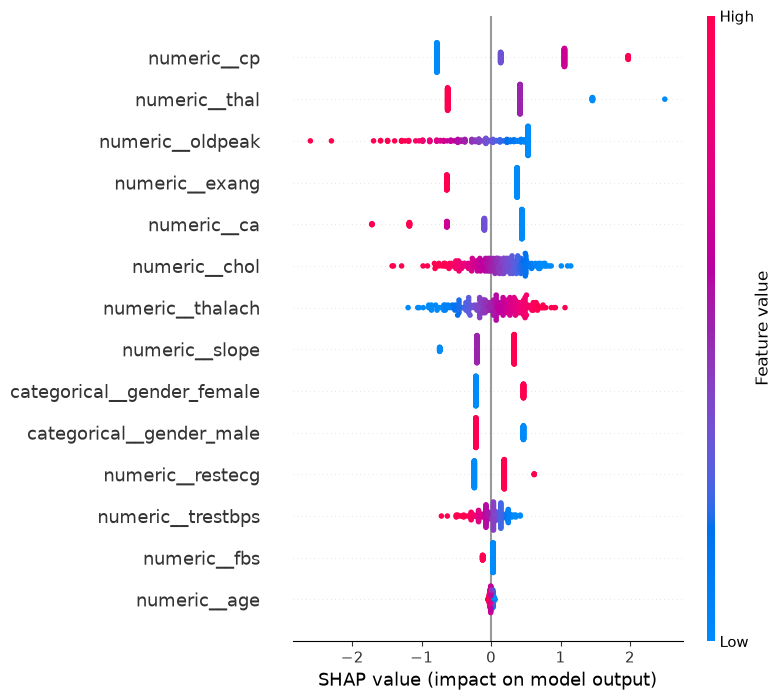

In [23]:
import shap
import matplotlib.pyplot as plt

# Transform training data
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get trained Logistic Regression
classifier = model.named_steps["classifier"]

# SHAP Linear Explainer
explainer = shap.LinearExplainer(
    classifier,
    X_train_transformed
)

shap_values = explainer(X_train_transformed)

# Global feature importance
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    show=True
)

In [24]:
# Calculate mean absolute SHAP importance
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Create feature-importance table
shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": shap_importance
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

print("SHAP Feature Importance:")
display(shap_importance_df)

SHAP Feature Importance:


,Feature,Mean_Absolute_SHAP
1,numeric__cp,0.826714
11,numeric__thal,0.570351
8,numeric__oldpeak,0.488873
7,numeric__exang,0.463715
10,numeric__ca,0.463597
3,numeric__chol,0.351474
6,numeric__thalach,0.349155
9,numeric__slope,0.303816
12,categorical__gender_female,0.297915
13,categorical__gender_male,0.297803


In [25]:
# Top 5 and least impactful features

print("TOP 5 MOST IMPACTFUL FEATURES")
display(shap_importance_df.head(5))

print("LEAST IMPACTFUL FEATURES")
display(shap_importance_df.tail(5))

TOP 5 MOST IMPACTFUL FEATURES


,Feature,Mean_Absolute_SHAP
1,numeric__cp,0.826714
11,numeric__thal,0.570351
8,numeric__oldpeak,0.488873
7,numeric__exang,0.463715
10,numeric__ca,0.463597


LEAST IMPACTFUL FEATURES


,Feature,Mean_Absolute_SHAP
13,categorical__gender_male,0.297803
5,numeric__restecg,0.221283
2,numeric__trestbps,0.148571
4,numeric__fbs,0.041513
0,numeric__age,0.016685


In [26]:
# D2: Plain-English SHAP explanation

top_features = shap_importance_df.head(5)
least_features = shap_importance_df.tail(5)

print("D2 - SHAP EXPLAINABILITY")
print("=" * 50)

print("\nMost impactful factors:")
for _, row in top_features.iterrows():
    print(
        f"- {row['Feature']}: "
        f"SHAP importance = {row['Mean_Absolute_SHAP']:.4f}"
    )

print("\nLeast impactful factors:")
for _, row in least_features.iterrows():
    print(
        f"- {row['Feature']}: "
        f"SHAP importance = {row['Mean_Absolute_SHAP']:.4f}"
    )

print("\nPlain-English interpretation:")
print(
    "SHAP values measure how much each feature contributes to the "
    "model's prediction. A larger mean absolute SHAP value indicates "
    "a greater overall influence on the prediction, while a smaller "
    "value indicates lower influence."
)

D2 - SHAP EXPLAINABILITY

Most impactful factors:
- numeric__cp: SHAP importance = 0.8267
- numeric__thal: SHAP importance = 0.5704
- numeric__oldpeak: SHAP importance = 0.4889
- numeric__exang: SHAP importance = 0.4637
- numeric__ca: SHAP importance = 0.4636

Least impactful factors:
- categorical__gender_male: SHAP importance = 0.2978
- numeric__restecg: SHAP importance = 0.2213
- numeric__trestbps: SHAP importance = 0.1486
- numeric__fbs: SHAP importance = 0.0415
- numeric__age: SHAP importance = 0.0167

Plain-English interpretation:
SHAP values measure how much each feature contributes to the model's prediction. A larger mean absolute SHAP value indicates a greater overall influence on the prediction, while a smaller value indicates lower influence.


In [27]:
%pip install --quiet fairlearn

Note: you may need to restart the kernel to use updated packages.


In [28]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predictions on test data
y_test_pred = model.predict(X_test)

# Age is the sensitive attribute
sensitive_age = X_test["age"]

# Fairness metrics by age group
metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "precision": precision_score,
        "recall": recall_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=y_test_pred,
    sensitive_features=sensitive_age
)

print("D3 - FAIRNESS ANALYSIS USING AGE")
print("=" * 50)

print("\nMetrics by Age:")
display(metric_frame.by_group)

print("\nOverall Metrics:")
display(metric_frame.overall)

print("\nDemographic Parity Difference:",
      demographic_parity_difference(
          y_test,
          y_test_pred,
          sensitive_features=sensitive_age
      ))

print("\nEqualized Odds Difference:",
      equalized_odds_difference(
          y_test,
          y_test_pred,
          sensitive_features=sensitive_age
      ))

D3 - FAIRNESS ANALYSIS USING AGE

Metrics by Age:


/opt/micromamba/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/micromamba/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/micromamba/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/micromamba/lib/python3.12/site-packages/sklearn/metrics/_classificati

,accuracy,precision,recall,selection_rate
age,,,,
35,1.000000,1.000000,1.0,0.666667
39,1.000000,1.000000,1.0,1.000000
41,1.000000,1.000000,1.0,1.000000
42,1.000000,1.000000,1.0,1.000000
43,1.000000,1.000000,1.0,1.000000
44,1.000000,0.000000,0.0,0.000000
45,1.000000,1.000000,1.0,1.000000
46,1.000000,1.000000,1.0,0.500000
48,1.000000,1.000000,1.0,1.000000



Overall Metrics:


accuracy          0.803279
precision         0.769231
recall            0.909091
selection_rate    0.639344
dtype: float64


Demographic Parity Difference: 1.0

Equalized Odds Difference: 1.0


In [29]:
print("D3 - FAIRNESS CONCLUSION")
print("=" * 50)

print("""
Sensitive attribute: Age

Overall model performance:
- Accuracy: 80.33%
- Precision: 76.92%
- Recall: 90.91%

Fairness results:
- Demographic Parity Difference: 1.00
- Equalized Odds Difference: 1.00

Interpretation:
The model shows differences in prediction outcomes across age groups.
A value of 0 for these fairness difference metrics would indicate
no measured disparity, while larger values indicate greater disparity.

The observed value of 1.00 indicates a substantial disparity in this
test set. However, many individual age groups contain very few samples,
so the group-level estimates can be unstable. Therefore, these results
should be interpreted as a fairness warning and not as evidence that
age alone causes the prediction differences.
""")

D3 - FAIRNESS CONCLUSION

Sensitive attribute: Age

Overall model performance:
- Accuracy: 80.33%
- Precision: 76.92%
- Recall: 90.91%

Fairness results:
- Demographic Parity Difference: 1.00
- Equalized Odds Difference: 1.00

Interpretation:
The model shows differences in prediction outcomes across age groups.
A value of 0 for these fairness difference metrics would indicate
no measured disparity, while larger values indicate greater disparity.

The observed value of 1.00 indicates a substantial disparity in this
test set. However, many individual age groups contain very few samples,
so the group-level estimates can be unstable. Therefore, these results
should be interpreted as a fairness warning and not as evidence that
age alone causes the prediction differences.

